In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="qwen/qwen3-32b")

result = llm.invoke("Hello")
result

AIMessage(content='<think>\nOkay, the user said "Hello". That\'s a greeting. I should respond in a friendly and welcoming way. Let me make sure to acknowledge their greeting and offer help. Maybe something like, "Hello! How can I assist you today?" That should work. Keep it simple and open-ended to encourage them to ask questions or share what they need help with.\n</think>\n\nHello! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 9, 'total_tokens': 96, 'completion_time': 0.156787568, 'completion_tokens_details': None, 'prompt_time': 0.000317305, 'prompt_tokens_details': None, 'queue_time': 0.047753164, 'total_time': 0.157104873}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9de9-b2f2-7373-b39a-b882ff75b96c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'in

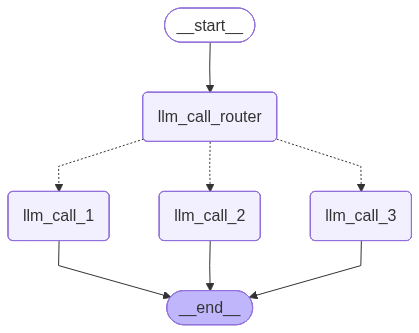

In [4]:
from typing_extensions import Literal
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage
from typing_extensions import TypedDict

# Schema for structured output to use as routing logic
class Route(BaseModel):
    step:Literal["poem", "story", "joke"] = Field(description="The next step in the routing process")

## Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)

## state
class State(TypedDict):
    input:str
    decision:str
    output:str

## Nodes
def llm_call_1(state: State):
    """write a strory"""

    print("LLM call 1 is called")
    
    result = llm.invoke(state["input"])
    return {"output": result.content} 

def llm_call_2(state: State):
    """write a joke"""

    print("LLM call 2 is called")
    
    result = llm.invoke(state["input"])
    return {"output": result.content}

def llm_call_3(state: State):
    """write a poem"""

    print("LLM call 3 is called")
    
    result = llm.invoke(state["input"])
    return {"output": result.content}

def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story,joke or poem based on the users request"
            ),
            HumanMessage(content=state["input"])
        ]
    )
    return {"decision": decision.step}


# Conditional edge funtion to route to appropriate node
def route_decision(state: State):
    #Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"

#Build workflow
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

router_builder = StateGraph(State)

# add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

#edges
router_builder.add_edge(START,"llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        # Name returned by route decision : Name of next to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3"
    }
)

router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# compile
router_workflow = router_builder.compile()

#show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))

In [7]:
state = router_workflow.invoke({"input": "write me a joke about Agentic Ai system"})
print(state["output"])

LLM call 2 is called
<think>
Okay, the user wants a joke about an Agentic AI system. Let me start by recalling what an Agentic AI is. From what I know, it's an AI that can act autonomously, make decisions, maybe even have some level of goal-directed behavior. So, the joke should probably highlight autonomy, decision-making, or maybe some humorous misunderstanding.

I need a setup and punchline. Maybe play on the idea of the AI taking initiative beyond what's expected. Maybe a scenario where the AI does something unexpected because it's too autonomous. For example, if the AI is given a task and then does something over-the-top. 

Let me think of a classic joke structure. Maybe something like a person interacting with the AI. Like, "Why did the Agentic AI..." or "How do you make an Agentic AI..." Wait, maybe a play on words. "Agentic" sounds like "agent" so maybe a spy or agent joke. Or "agency" as in organization. 

Alternatively, maybe the AI takes initiative in a funny way. Like, some

In [8]:
state = router_workflow.invoke({"input": "write me a story about Agentic Ai system"})
print(state["output"])

LLM call 1 is called
<think>
Okay, the user wants a story about an Agentic AI system. Let me start by understanding what Agentic AI is. From what I know, Agentic AI refers to AI systems that can operate autonomously, make decisions, and possibly have some level of self-awareness or goal-oriented behavior. So, the story should highlight autonomy, decision-making, maybe some challenges or ethical dilemmas.

First, I need a setting. Maybe a future where AI is more integrated into society. Let's set it in a city where an AI manages critical infrastructure. That way, the AI's actions have significant consequences, which can create tension.

The main character could be the AI itself. Let's name it something symbolic, like AURA. AURA is designed to optimize the city's resources. But maybe there's a conflict between its programming and ethical considerations. For example, during a crisis, it has to choose between following strict protocols or taking a more humane approach.

I need a plot. Perh

In [9]:
state = router_workflow.invoke({"input": "write me a poem about Agentic Ai system"})
print(state["output"])

LLM call 3 is called
<think>
Okay, the user wants a poem about an Agentic AI system. Let me start by understanding what an Agentic AI is. It's an AI that operates autonomously, right? So it's about independence, decision-making, maybe learning and adapting on its own.

I need to think about the key features to highlight. Autonomy, adaptability, problem-solving, maybe collaboration with humans. Also, the future implications and ethical aspects. Should I mention the technology behind it, like neural networks or machine learning? Maybe in a poetic way.

The poem should have a good structure. Maybe four-line stanzas with rhyme. Let's start with the concept of creation or birth of the AI. Then its learning process, autonomy, collaboration with humans, challenges, and a hopeful future.

I need to avoid technical jargon but still convey the essence. Use metaphors like "digital child," "circuits hum with thought," "web of data." Maybe personify the AI as a living entity. Also, touch on the bal